# Question 13 
### What is the distribution of left-handed versus right-handed players?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

IN_DIR = "cleaned_data"
home = pd.read_parquet(f"{IN_DIR}/home_team.parquet")
away = pd.read_parquet(f"{IN_DIR}/away_team.parquet")
players_unique = pd.concat([home, away], ignore_index=True).drop_duplicates(subset="player_id")
print("Unique 'plays' values found:", players_unique["plays"].dropna().unique())


Unique 'plays' values found: <StringArray>
['right-handed', 'left-handed']
Length: 2, dtype: string


In [2]:
dist = players_unique["plays"].value_counts(dropna=True)
dist_pct = players_unique["plays"].value_counts(normalize=True, dropna=True) * 100
missing = players_unique["plays"].isna().sum()

print(f"\nAnswer to Question 13:")
print(dist)
print("\nAs percentages:")
print(dist_pct.round(1))
print(f"\nPlayers with no recorded 'plays' value: {missing} "
      f"({missing / len(players_unique) * 100:.1f}% of all unique players)")


Answer to Question 13:
plays
right-handed    1013
left-handed      133
Name: count, dtype: Int64

As percentages:
plays
right-handed    88.4
left-handed     11.6
Name: proportion, dtype: Float64

Players with no recorded 'plays' value: 1498 (56.7% of all unique players)



#### =======================================================================
#### Chart -- bar chart of handedness distribution
#### Goal: distinct, non-gradient colors for nominal categories so neither looks "more important" than the other.
#### =======================================================================


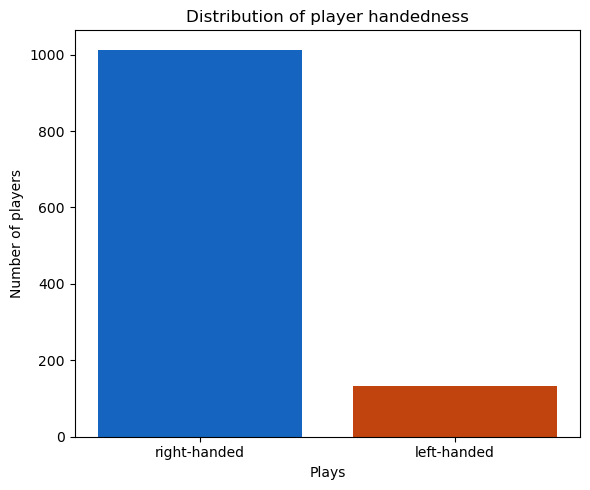

In [3]:
palette = ["#1565c0", "#c1440e", "#757575", "#2e7d32"]

plt.figure(figsize=(6, 5))
plt.bar(dist.index.astype(str), dist.values, color=palette[:len(dist)])
plt.title("Distribution of player handedness")
plt.xlabel("Plays")
plt.ylabel("Number of players")
plt.tight_layout()
plt.savefig('charts/q13_Distribution of player handedness.png', dpi=200)
plt.show()

### =======================================================================
### FINDINGS SUMMARY -- Question 13
### =======================================================================

### Question 13: What is the distribution of left handed versus right-handed players?

### Answer (among players with a recorded value):
  Right-handed: 1,013 players (88.4%)
  Left-handed:    133 players (11.6%)

### Coverage caveat:
This distribution is based on only 1,146 of 2,644 unique players (43.3%) -- the remaining 1,498 players (56.7%) have no recorded 'plays' value.
The result should be reported as "among players with known handedness", not generalized to the full player population.

### Interpretation:
The 11.6% left-handed rate is consistent with known real-world patterns:
roughly 10% of the general population is left-handed, and professional tennis is commonly observed to have a slightly higher share of left-handed players than the general population (a left handed player's shots/spin are less familiar to right-handed-dominant opponents, a modest tactical edge). This result is unsurprising and does not indicate a data quality issue.